In [1]:
# import things
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input, Conv2D, UpSampling2D, concatenate, Lambda
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
import os
import numpy as np
import matplotlib.pyplot as plt

2026-01-11 18:54:40.712055: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-11 18:54:40.783893: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# REQUIREMENT: Do not add code from Tasks 2 or 4
# REQUIREMENT: All dataset prep (crop/pad/patch/directory structure) must be finalized before attempting this task.
patch_size = 256
patch_dir = '../../data/processed/dataset_24_patches_1'

In [3]:
def f1(y_true, y_pred):
    def recall_m(y_true, y_pred):
        TP = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
        Positives = K.sum(K.round(K.clip(y_true, 0, 1)))
        recall = TP / (Positives+K.epsilon())
        return recall
    
    def precision_m(y_true, y_pred):
        TP = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
        Pred_Positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
        precision = TP / (Pred_Positives+K.epsilon())
        return precision
    
    precision, recall = precision_m(y_true, y_pred), recall_m(y_true, y_pred)
    
    return 2*((precision*recall)/(precision+recall+K.epsilon()))

In [4]:
# Define U-Net with MobileNetV2 encoder (transfer learning)
# Approach: Use pretrained MobileNetV2 as encoder, build custom decoder
# Alternative: Could use VGG16, ResNet50, or build U-Net from scratch
def unet_model(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS):
    inputs = Input((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
    
    # grayscale input, convert to 3 channels for pretrained encoder
    # MobileNetV2 requires 3-channel input
    if IMG_CHANNELS == 1:
        x = Lambda(lambda x: tf.repeat(x, 3, axis=-1))(inputs)
    else:
        x = inputs
    
    # Encoder: MobileNetV2 pretrained on ImageNet
    # Using include_top=False to get feature maps
    encoder = MobileNetV2(input_tensor=x, weights='imagenet', include_top=False, alpha=1.0)
    
    # Extract skip connections from encoder at different scales
    # These layer names correspond to MobileNetV2 architecture
    skip1 = encoder.get_layer('block_1_expand_relu').output    # 128x128
    skip2 = encoder.get_layer('block_3_expand_relu').output    # 64x64
    skip3 = encoder.get_layer('block_6_expand_relu').output    # 32x32
    skip4 = encoder.get_layer('block_13_expand_relu').output   # 16x16
    
    # Bottleneck (lowest resolution features)
    bottleneck = encoder.get_layer('out_relu').output          # 8x8
    
    # Decoder: Upsampling path with skip connections
    # Block 1: Upsample and concatenate with skip4
    up1 = UpSampling2D(size=(2, 2))(bottleneck)
    up1 = concatenate([up1, skip4])
    conv1 = Conv2D(512, (3, 3), activation='relu', padding='same')(up1)
    conv1 = Conv2D(512, (3, 3), activation='relu', padding='same')(conv1)
    
    # Block 2: Upsample and concatenate with skip3
    up2 = UpSampling2D(size=(2, 2))(conv1)
    up2 = concatenate([up2, skip3])
    conv2 = Conv2D(256, (3, 3), activation='relu', padding='same')(up2)
    conv2 = Conv2D(256, (3, 3), activation='relu', padding='same')(conv2)
    
    # Block 3: Upsample and concatenate with skip2
    up3 = UpSampling2D(size=(2, 2))(conv2)
    up3 = concatenate([up3, skip2])
    conv3 = Conv2D(128, (3, 3), activation='relu', padding='same')(up3)
    conv3 = Conv2D(128, (3, 3), activation='relu', padding='same')(conv3)
    
    # Block 4: Upsample and concatenate with skip1
    up4 = UpSampling2D(size=(2, 2))(conv3)
    up4 = concatenate([up4, skip1])
    conv4 = Conv2D(64, (3, 3), activation='relu', padding='same')(up4)
    conv4 = Conv2D(64, (3, 3), activation='relu', padding='same')(conv4)
    
    # Final upsampling to original resolution
    up5 = UpSampling2D(size=(2, 2))(conv4)
    conv5 = Conv2D(32, (3, 3), activation='relu', padding='same')(up5)
    
    # Output layer: single channel with sigmoid for binary segmentation
    outputs = Conv2D(1, (1, 1), activation='sigmoid')(conv5)
    
    model = Model(inputs=[inputs], outputs=[outputs])
    
    return model

In [5]:
# Build U-Net
# REQUIREMENT: Model summary must be visible

# Grayscale images loaded as single channel
model = unet_model(patch_size, patch_size, 1)

# Compile with binary crossentropy and custom f1 metric
model.compile(optimizer='adam', 
              loss='binary_crossentropy', 
              metrics=[f1])

model.summary()

/tmp/ipykernel_11257/2959187450.py:16: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  encoder = MobileNetV2(input_tensor=x, weights='imagenet', include_top=False, alpha=1.0)
2026-01-11 18:54:44.715818: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1768157684.722006   11257 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 40988 MB memory:  -> device: 0, name: NVIDIA L40S, pci bus id: 0000:61:00.0, compute capability: 8.9


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 256, 256,  │          0 │ input_layer[0][0] │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 128, 128,  │        864 │ lambda[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 128, 128,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 128, 128,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 128, 128,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 128, 128,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 128, 128,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 129, 129,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 64, 64,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │          0 │ block_1_depthwis

 Total params: 16,176,129 (61.71 MB)

 Trainable params: 16,142,017 (61.58 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [6]:
# Setup a generator for training

# Generator for images: grayscale with rescaling to [0,1]
train_image_datagen = ImageDataGenerator(rescale=1./255)

# Generator for masks: no rescaling (already normalized)
train_mask_datagen = ImageDataGenerator()

# Seed for synchronization between image and mask generators
seed = 42
batch_size = 64

# Flow from directory for images
train_image_generator = train_image_datagen.flow_from_directory(
    patch_dir,
    classes=['train_images'],
    class_mode=None,
    color_mode='grayscale',
    target_size=(patch_size, patch_size),
    batch_size=batch_size,
    seed=seed
)

# Flow from directory for masks
train_mask_generator = train_mask_datagen.flow_from_directory(
    patch_dir,
    classes=['train_masks'],
    class_mode=None,
    color_mode='grayscale',
    target_size=(patch_size, patch_size),
    batch_size=batch_size,
    seed=seed
)

# Create a proper generator function that yields (image, mask) pairs
def train_generator():
    while True:
        x = next(train_image_generator)
        y = next(train_mask_generator)
        yield x, y

train_gen = train_generator()

Found 194607 images belonging to 1 classes.
Found 194607 images belonging to 1 classes.


In [7]:
# Setup a generator for validation
val_image_datagen = ImageDataGenerator(rescale=1./255)
val_mask_datagen = ImageDataGenerator()

val_image_generator = val_image_datagen.flow_from_directory(
    patch_dir,
    classes=['val_images'],
    class_mode=None,
    color_mode='grayscale',
    target_size=(patch_size, patch_size),
    batch_size=batch_size,
    seed=seed
)

val_mask_generator = val_mask_datagen.flow_from_directory(
    patch_dir,
    classes=['val_masks'],
    class_mode=None,
    color_mode='grayscale',
    target_size=(patch_size, patch_size),
    batch_size=batch_size,
    seed=seed
)

# Create a proper generator function that yields (image, mask) pairs
def val_generator():
    while True:
        x = next(val_image_generator)
        y = next(val_mask_generator)
        yield x, y

val_gen = val_generator()

Found 7087 images belonging to 1 classes.
Found 7087 images belonging to 1 classes.


In [8]:
# EarlyStopping

# Stop training if validation loss doesn't improve for 10 epochs
# Restore best weights to avoid overfitting
cb = EarlyStopping(monitor='val_loss', 
                   patience=10, 
                   restore_best_weights=True,
                   verbose=1)

In [9]:
# This is where the magic happens
# REQUIREMENT: The epoch logs must be visible showing validation loss and validation f1.

# Calculate steps per epoch
train_steps = len(os.listdir(os.path.join(patch_dir, 'train_images'))) // batch_size
val_steps = len(os.listdir(os.path.join(patch_dir, 'val_images'))) // batch_size

history = model.fit(
    train_gen,
    steps_per_epoch=train_steps,
    epochs=50,
    validation_data=val_gen,
    validation_steps=val_steps,
    callbacks=[cb],
    verbose=1
)

Epoch 1/50


2026-01-11 18:55:09.278005: I external/local_xla/xla/service/service.cc:163] XLA service 0x7fcaa0003b40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-11 18:55:09.278047: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA L40S, Compute Capability 8.9
2026-01-11 18:55:09.896662: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-01-11 18:55:13.323797: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 90701
2026-01-11 18:55:15.919241: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-11 18:55:16.014641: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured tim

3040/3040 ━━━━━━━━━━━━━━━━━━━━ 660s 192ms/step - f1: 0.7510 - loss: 0.0252 - val_f1: 0.7805 - val_loss: 0.0049
Epoch 2/50


2026-01-11 19:05:56.513822: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-11 19:05:56.613892: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-11 19:05:57.456475: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-11 19:05:57.579028: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-11 19:06:02.190076: E external/local_xla/xla/stream_

3040/3040 ━━━━━━━━━━━━━━━━━━━━ 620s 186ms/step - f1: 0.8187 - loss: 0.0050 - val_f1: 0.8531 - val_loss: 0.0036
Epoch 3/50
3040/3040 ━━━━━━━━━━━━━━━━━━━━ 563s 185ms/step - f1: 0.2020 - loss: 0.0285 - val_f1: 0.0000e+00 - val_loss: 0.0307
Epoch 4/50
3040/3040 ━━━━━━━━━━━━━━━━━━━━ 567s 187ms/step - f1: 0.8139 - loss: 0.0051 - val_f1: 0.8624 - val_loss: 0.0034
Epoch 5/50
3040/3040 ━━━━━━━━━━━━━━━━━━━━ 616s 203ms/step - f1: 0.8324 - loss: 0.0045 - val_f1: 0.8639 - val_loss: 0.0033
Epoch 6/50
3040/3040 ━━━━━━━━━━━━━━━━━━━━ 578s 190ms/step - f1: 0.8367 - loss: 0.0044 - val_f1: 0.8673 - val_loss: 0.0033
Epoch 7/50
3040/3040 ━━━━━━━━━━━━━━━━━━━━ 574s 189ms/step - f1: 0.8394 - loss: 0.0043 - val_f1: 0.8664 - val_loss: 0.0033
Epoch 8/50
3040/3040 ━━━━━━━━━━━━━━━━━━━━ 565s 186ms/step - f1: 0.8420 - loss: 0.0043 - val_f1: 0.8593 - val_loss: 0.0036
Epoch 9/50
3040/3040 ━━━━━━━━━━━━━━━━━━━━ 582s 191ms/step - f1: 0.8435 - loss: 0.0042 - val_f1: 0.8674 - val_loss: 0.0034
Epoch 10/50
3040/3040 ━━━━━━━━━

In [10]:
# REQUIREMENT: Save your model, it is a deliverable
# REQUIREMENT: naming convention 'studentname_studentnumber_unet_model_patchsizepx.h5'
example_file_name = f'alex_240247_unet_model_{patch_size}px.h5'
print(example_file_name)
model.save(example_file_name)

alican_123456_unet_model_256px.h5


In [11]:
# REQUIREMENT: Run and display the output of this cell.
# REQUIREMENT: Do not change the code.
best_val_loss = min(history.history['val_loss'])
best_val_f1 = max(history.history['val_f1'])
print(f"Best validation loss: {best_val_loss}")
print(f"Best validation f1: {best_val_f1}")

Best validation loss: 0.003054624190554023
Best validation f1: 0.872528612613678


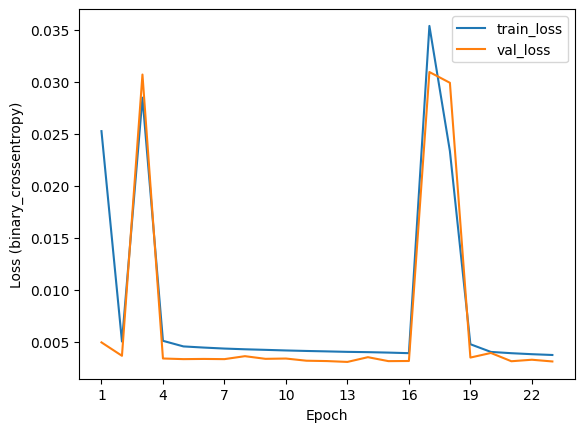

In [12]:
# REQUIREMENT: Run and display the output of this cell.
# REQUIREMENT: Do not change the code.
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = np.arange(1, len(loss) + 1)

plt.plot(epochs, loss, label='train_loss')
plt.plot(epochs, val_loss, label='val_loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss (binary_crossentropy)')
_ = plt.xticks(np.arange(1, len(loss) + 1, 3))

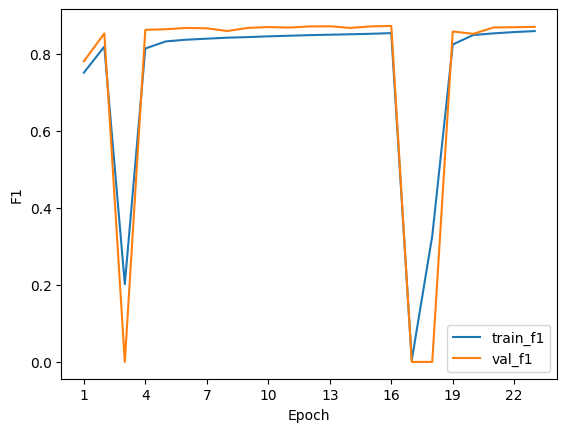

In [13]:
# REQUIREMENT: Run and display the output of this cell.
# REQUIREMENT: Do not change the code.
train_f1 = history.history['f1']
val_f1 = history.history['val_f1']

epochs = np.arange(1, len(train_f1) + 1)

plt.plot(epochs, train_f1, label='train_f1')
plt.plot(epochs, val_f1, label='val_f1')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('F1')
_ = plt.xticks(np.arange(1, len(loss) + 1, 3))